In [50]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, train_test_split, RandomizedSearchCV
import json
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import matplotlib.pyplot as plt

# Hàm Target Encoding có KFold
def target_encode_kfold(df, column, target, n_fold=5, alpha=5):
    """
    Performs target encoding with k-fold cross-validation to prevent data leakage.
    
    Parameters:
    -----------
    df : pandas DataFrame
        The dataframe containing the data
    column : str
        The name of the categorical column to encode
    target : str
        The name of the target column
    n_fold : int, default=5
        Number of folds for cross-validation
    alpha : float, default=5
        Regularization parameter
        
    Returns:
    --------
    pandas Series
        The encoded values for the column
    """
    # Create a copy of the dataframe
    df_copy = df.copy()
    
    # Calculate the global mean
    global_mean = df_copy[target].mean()
    
    # Create the output Series
    encoded = pd.Series(index=df_copy.index)
    
    # Split the data into n_fold parts
    kf = KFold(n_splits=n_fold, shuffle=True, random_state=42)
    
    for train_idx, test_idx in kf.split(df_copy):
        # Calculate the mean target for each category in the training fold
        means = df_copy.iloc[train_idx].groupby(column)[target].agg(['mean', 'count'])
        
        # Apply regularization
        smoothed_means = ((means['mean'] * means['count']) + (global_mean * alpha)) / (means['count'] + alpha)
        
        # Map the means to the test fold
        encoded.iloc[test_idx] = df_copy.iloc[test_idx][column].map(smoothed_means)
    
    # Handle any categories that weren't seen in the training data (use global mean)
    encoded.fillna(global_mean, inplace=True)
    
    return encoded

In [51]:
# Bước 1: Đọc dữ liệu
train_file = '../../data/datasets/train_stratified_by_chip_model.csv'
test_file = '../../data/datasets/test_stratified_by_chip_model.csv'

train_df = pd.read_csv(train_file)
test_df = pd.read_csv(test_file)

# Các cột cần encoding và cột mục tiêu
categorical_cols = ['chip_model', 'brand', 'screen_tech', 'screen_resolution_k']
target_col = 'price'

# Lưu lại mean của các categorical features
encoding_means = {}
encoding_means_path = './datasets/encoding_means.json'


In [52]:
# Bước 2: Target Encoding
for col in categorical_cols:
    print(f"Encoding {col}...")
    train_df[f'{col}_encoded'] = target_encode_kfold(
        train_df, column=col, target=target_col, n_fold=5, alpha=10
    )
    # Lưu mean của từng category
    encoding_means[col] = train_df.groupby(col)[f'{col}_encoded'].mean().to_dict()

# Lưu encoding_means vào file JSON
with open(encoding_means_path, 'w') as f:
    json.dump(encoding_means, f)
print(f"Saved encoding means to ${encoding_means_path}")

# Áp dụng encoding cho tập test
for col in categorical_cols:
    test_df[f'{col}_encoded'] = test_df[col].map(encoding_means[col]).fillna(train_df[target_col].mean())



Encoding chip_model...
Encoding brand...
Encoding screen_tech...
Encoding screen_resolution_k...
Saved encoding means to $./datasets/encoding_means.json


In [53]:
# Bước 3: Chuẩn bị dữ liệu
features = ['ram', 'internal_memory', 'screen_size', 'refresh_rate', 
            'camera_main_resolution', 'camera_count', 'chip_model_encoded', 
            'brand_encoded', 'screen_tech_encoded', 'screen_resolution_k_encoded']
target = 'price'

X_train = train_df[features]
y_train = train_df[target_col]
X_test = test_df[features]
y_test = test_df[target_col]

In [54]:
# Bước 4: Tối ưu hóa siêu tham số
param_dist = {
    'n_estimators': [100, 300, 500, 600, 800],
    'learning_rate': [0.01, 0.005, 0.001],
    'max_depth': [3, 5, 6, 8],
    'subsample': [0.6, 0.8, 1.0],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 3, 5]
}

gb_base = GradientBoostingRegressor(random_state=42)

random_search = RandomizedSearchCV(
    gb_base,
    param_distributions=param_dist,
    n_iter=30,
    cv=3,
    verbose=2,
    n_jobs=-1,
    scoring='neg_mean_absolute_error',
    random_state=42
)

print("Tuning hyperparameters...")
random_search.fit(X_train, y_train)
best_model = random_search.best_estimator_

print("✅ Best Hyperparameters:")
print(random_search.best_params_)

Tuning hyperparameters...
Fitting 3 folds for each of 30 candidates, totalling 90 fits
[CV] END learning_rate=0.01, max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=100, subsample=0.6; total time=   0.3s
[CV] END learning_rate=0.01, max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=100, subsample=0.6; total time=   0.2s
[CV] END learning_rate=0.001, max_depth=8, min_samples_leaf=5, min_samples_split=5, n_estimators=100, subsample=0.6; total time=   0.3s
[CV] END learning_rate=0.01, max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=100, subsample=0.6; total time=   0.3s
[CV] END learning_rate=0.001, max_depth=8, min_samples_leaf=5, min_samples_split=5, n_estimators=100, subsample=0.6; total time=   0.3s
[CV] END learning_rate=0.001, max_depth=8, min_samples_leaf=5, min_samples_split=5, n_estimators=100, subsample=0.6; total time=   0.3s
[CV] END learning_rate=0.005, max_depth=6, min_samples_leaf=1, min_samples_split=2, n_estimators=100

Evaluating model...
MAE: 2224047.219967426
RMSE: 3343939.2252741167
R²: 0.8443367450467516
Saving best model...
✅ Saved best model to 'best_gb_model.pkl'


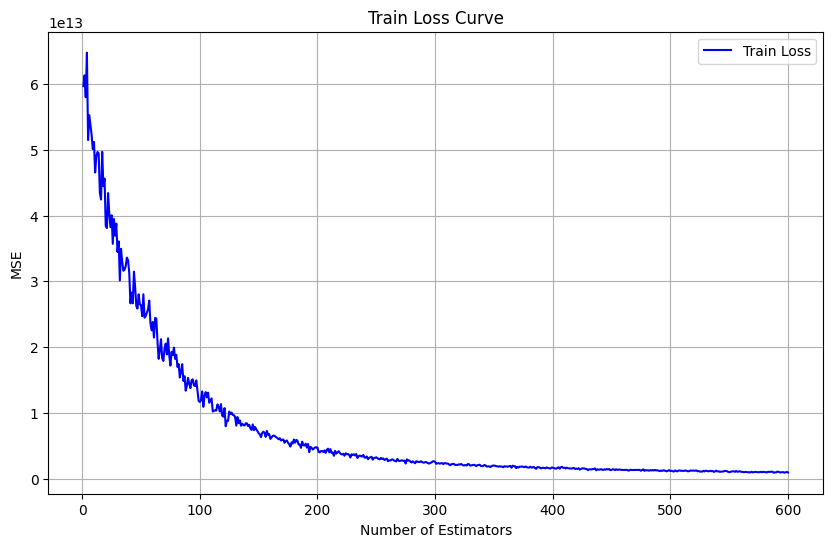

In [55]:
# Bước 6: Lưu model
print("Evaluating model...")
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R²: {r2}")

# Lưu model tốt nhất
print("Saving best model...")
joblib.dump(best_model, 'best_gb_model.pkl')
print("✅ Saved best model to 'best_gb_model.pkl'")

# Bước 7: Trực quan hóa loss trên tập train
plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, len(best_model.train_score_) + 1), best_model.train_score_, label='Train Loss', color='blue')
plt.xlabel('Number of Estimators')
plt.ylabel('MSE')
plt.title('Train Loss Curve')
plt.legend()
plt.grid()
plt.show()

Test

In [56]:
import pandas as pd
import joblib
import json

# Đường dẫn đến file trọng số và encoding means
model_file = 'gradient_boosting_model.pkl'
encoding_means_file = './datasets/encoding_means.json'

# Tải mô hình đã lưu
model = joblib.load(model_file)
print("Model loaded successfully!")

# Tải encoding means
with open(encoding_means_file, 'r') as f:
    encoding_means = json.load(f)
print("Encoding means loaded successfully!")

# Đọc tập test
test_file = '../../data/datasets/test_stratified_by_chip_model.csv'
test_df = pd.read_csv(test_file)

# Các cột cần mã hóa
categorical_cols = ['chip_model', 'brand', 'screen_tech', 'screen_resolution_k']

# Áp dụng encoding cho tập test
for col in categorical_cols:
    test_df[f'{col}_encoded'] = test_df[col].map(encoding_means[col]).fillna(0)

# Các cột đặc trưng
features = ['ram', 'internal_memory', 'screen_size', 'refresh_rate', 
            'camera_main_resolution', 'camera_count', 'chip_model_encoded', 
            'brand_encoded', 'screen_tech_encoded', 'screen_resolution_k_encoded']

# Chuẩn bị dữ liệu
X_test = test_df[features]

# Dự đoán
y_pred = model.predict(X_test)

# Lưu kết quả dự đoán
test_df['predicted_price'] = y_pred
output_file = 'test_predictions.csv'
test_df.to_csv(output_file, index=False)
print(f"Predictions saved to {output_file}")

FileNotFoundError: [Errno 2] No such file or directory: 'gradient_boosting_model.pkl'

### 1. Trực quan hóa hiệu suất mô hình
- a. Biểu đồ so sánh giá trị thực tế và giá trị dự đoán
    - Mục đích: Để kiểm tra mức độ khớp giữa giá trị thực tế (y_test) và giá trị dự đoán (y_pred).
    - Cách thực hiện:

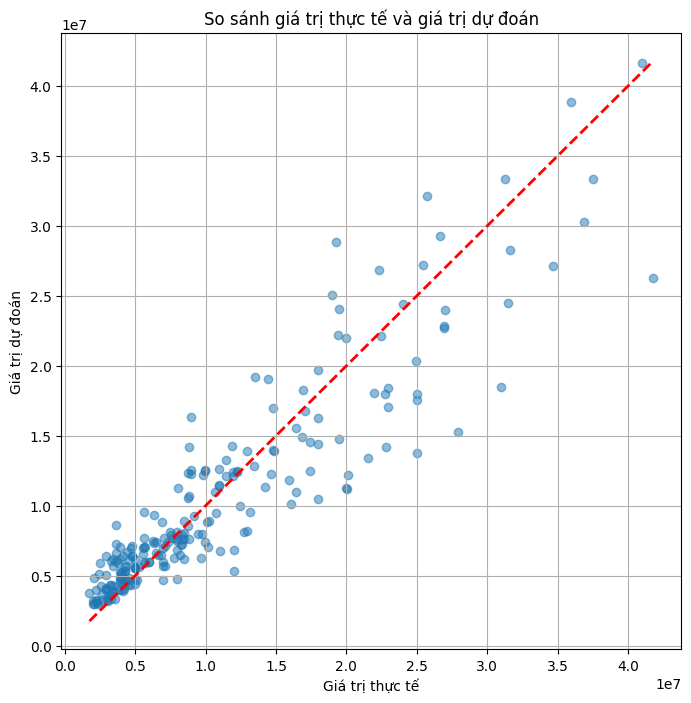

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Biểu đồ scatter giữa giá trị thực tế và giá trị dự đoán
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Giá trị thực tế')
plt.ylabel('Giá trị dự đoán')
plt.title('So sánh giá trị thực tế và giá trị dự đoán')
plt.grid()
plt.show()

b. Biểu đồ phân phối sai số (Residual Plot)
- Mục đích: Để kiểm tra xem sai số có phân phối ngẫu nhiên hay không.
- Cách thực hiện:

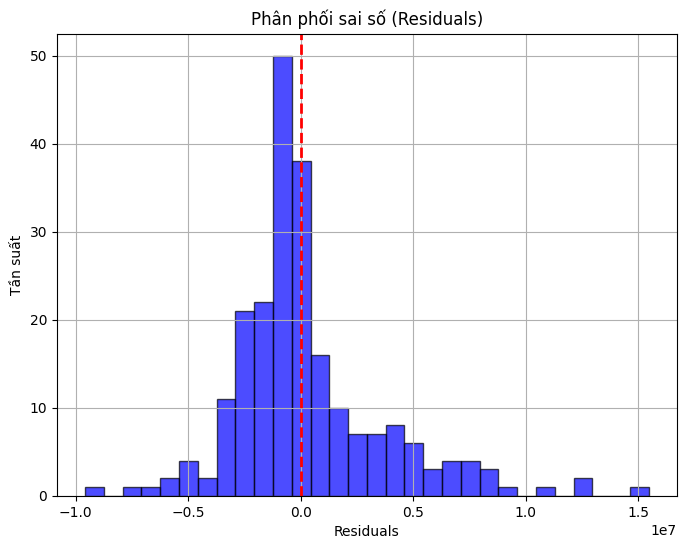

In [ ]:
# Tính residuals
residuals = y_test - y_pred

# Biểu đồ phân phối residuals
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=30, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Residuals')
plt.ylabel('Tần suất')
plt.title('Phân phối sai số (Residuals)')
plt.grid()
plt.show()

### 2. Trực quan hóa tầm quan trọng của đặc trưng (Feature Importance)
- Mục đích: Để hiểu đặc trưng nào đóng vai trò quan trọng nhất trong việc dự đoán.
- Cách thực hiện:

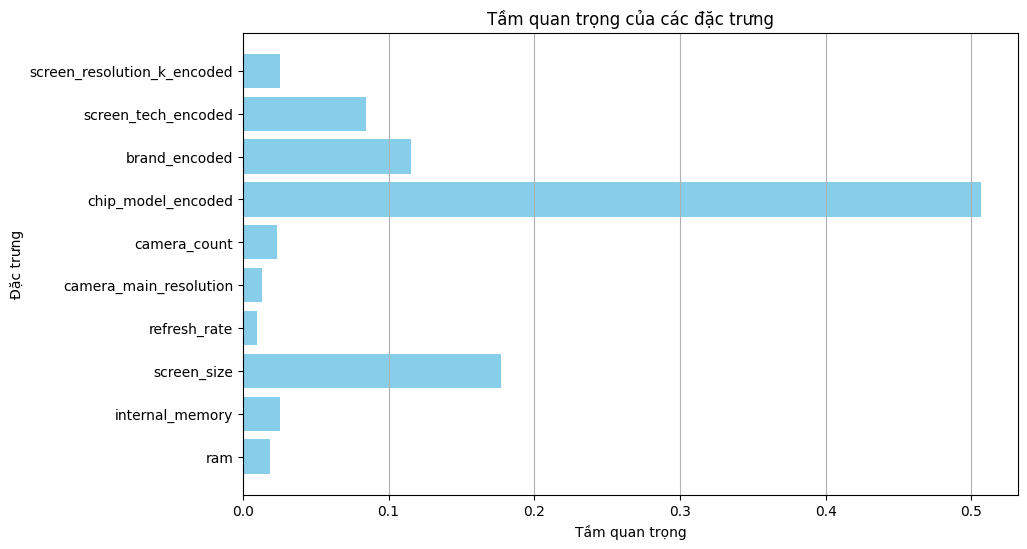

In [ ]:
# Lấy tầm quan trọng của đặc trưng từ mô hình
feature_importances = model.feature_importances_
feature_names = features

# Biểu đồ cột cho tầm quan trọng của đặc trưng
plt.figure(figsize=(10, 6))
plt.barh(feature_names, feature_importances, color='skyblue')
plt.xlabel('Tầm quan trọng')
plt.ylabel('Đặc trưng')
plt.title('Tầm quan trọng của các đặc trưng')
plt.grid(axis='x')
plt.show()

### 3. Trực quan hóa mối quan hệ giữa đặc trưng và giá trị mục tiêu
- a. Biểu đồ scatter giữa đặc trưng quan trọng nhất và giá trị mục tiêu
    - Mục đích: Để kiểm tra mối quan hệ giữa đặc trưng quan trọng nhất và giá trị mục tiêu (price).
    - Cách thực hiện:

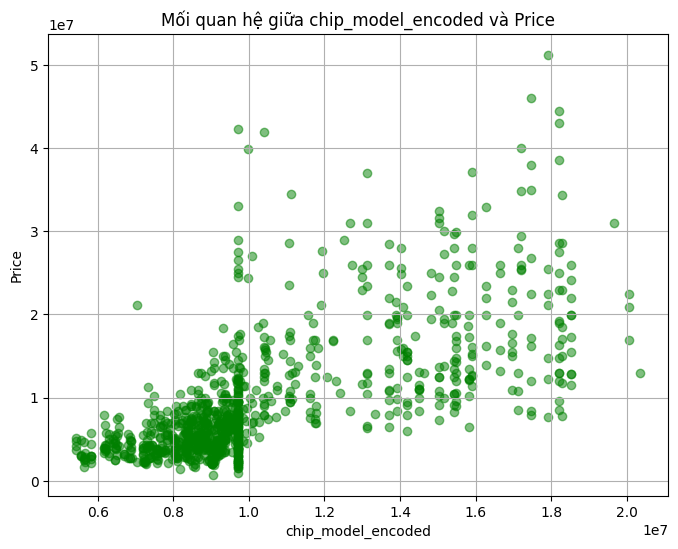

In [ ]:
# Chọn đặc trưng quan trọng nhất
most_important_feature = feature_names[np.argmax(feature_importances)]

# Biểu đồ scatter
plt.figure(figsize=(8, 6))
plt.scatter(train_df[most_important_feature], train_df[target], alpha=0.5, color='green')
plt.xlabel(most_important_feature)
plt.ylabel('Price')
plt.title(f'Mối quan hệ giữa {most_important_feature} và Price')
plt.grid()
plt.show()

### 4. Trực quan hóa phân phối giá trị thực tế và giá trị dự đoán
- Mục đích: Để kiểm tra xem phân phối của giá trị dự đoán có khớp với giá trị thực tế hay không.
- Cách thực hiện:

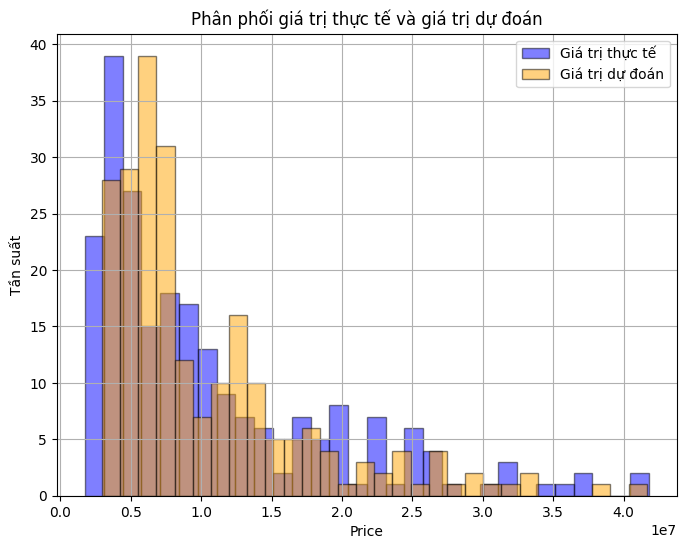

In [ ]:
# Biểu đồ phân phối giá trị thực tế và giá trị dự đoán
plt.figure(figsize=(8, 6))
plt.hist(y_test, bins=30, alpha=0.5, label='Giá trị thực tế', color='blue', edgecolor='black')
plt.hist(y_pred, bins=30, alpha=0.5, label='Giá trị dự đoán', color='orange', edgecolor='black')
plt.xlabel('Price')
plt.ylabel('Tần suất')
plt.title('Phân phối giá trị thực tế và giá trị dự đoán')
plt.legend()
plt.grid()
plt.show()

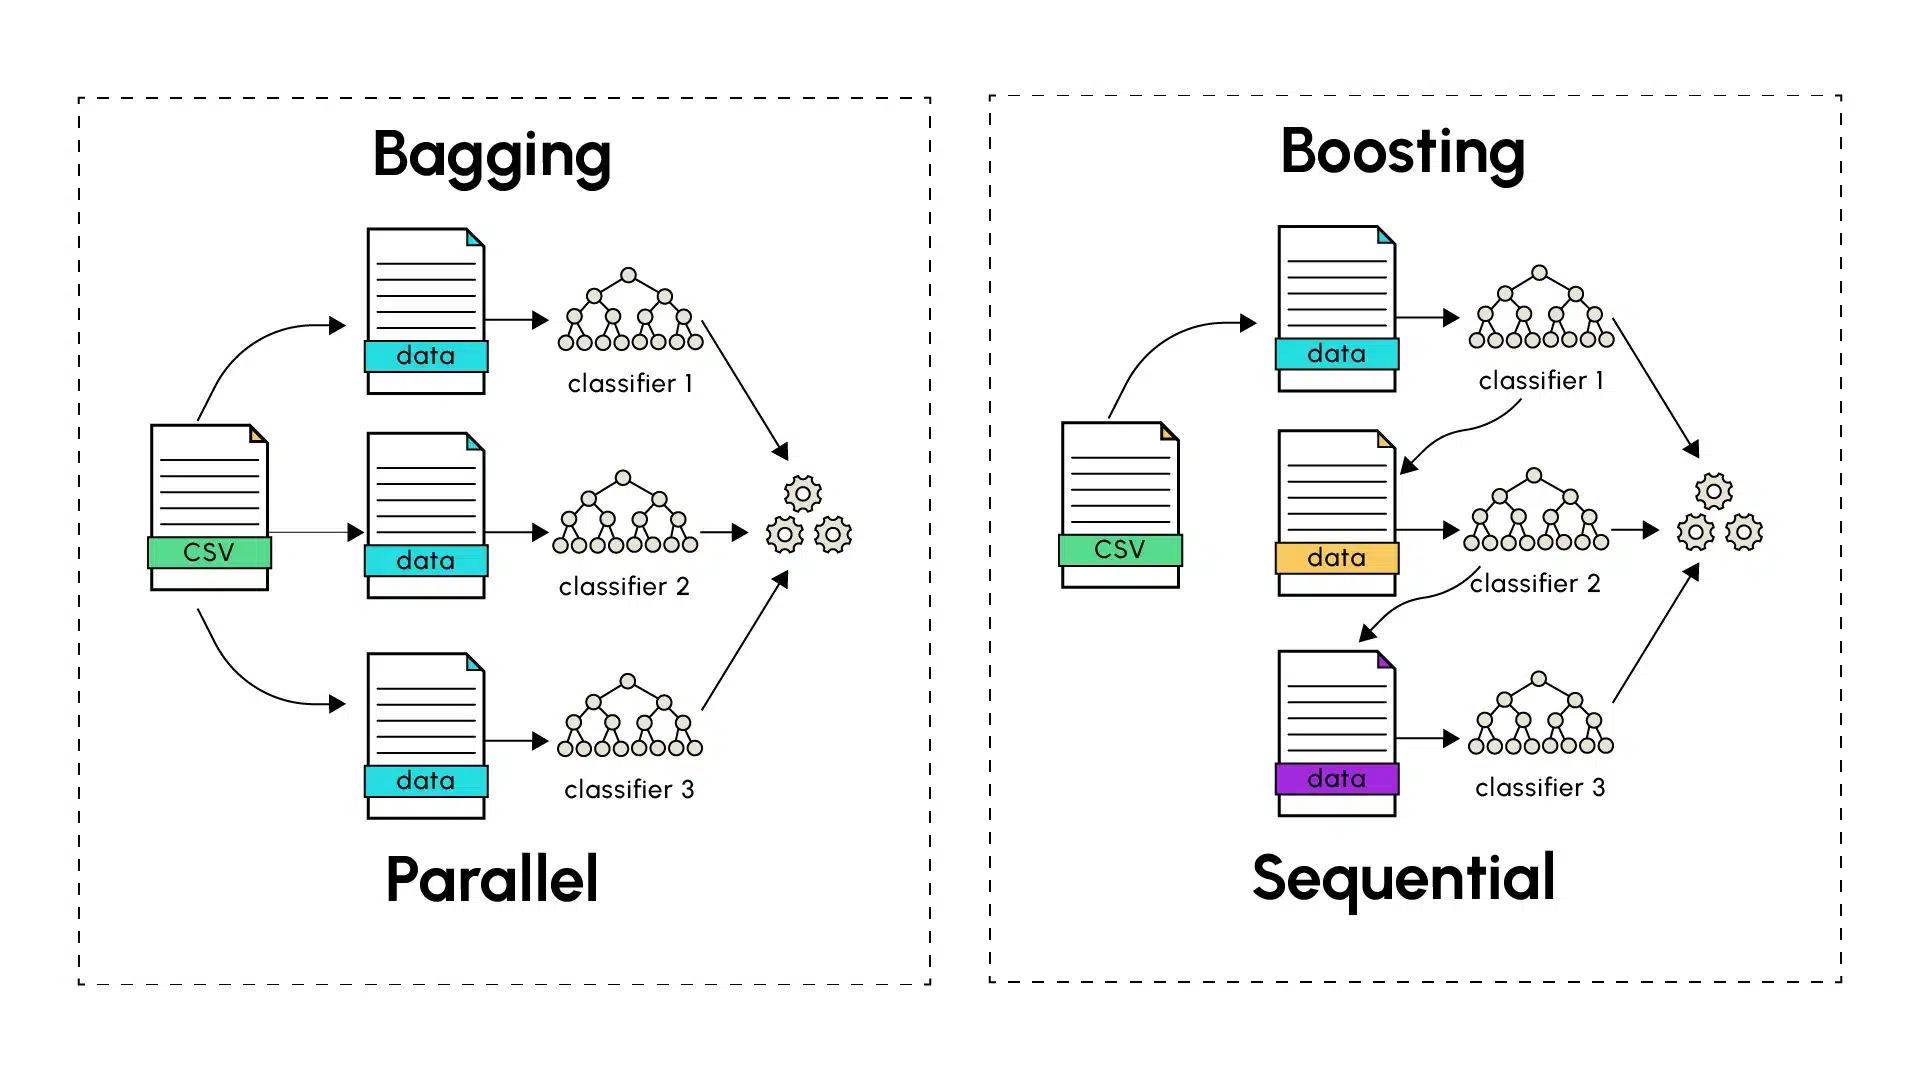

**Tên mô hình: Gradient Boosting (GBM)**

- Là mô hình ensemble kết hợp nhiều cây quyết định để cải thiện dự đoán qua từng bước.
- Tại mỗi bước boosting, mô hình mới học theo **gradient âm của hàm mất mát** để sửa lỗi từ mô hình trước.

**Loss function:**

- Với hồi quy: Mean Squared Error (MSE)
- Với phân loại nhị phân: Binary Cross Entropy (Log Loss)

**Các siêu tham số quan trọng:**

- `n_estimators`: số lượng cây (số vòng boosting).
- `learning_rate`: hệ số giảm tốc của mỗi cây mới (tránh overfitting).
- `max_depth`: độ sâu tối đa của mỗi cây con.
- `subsample`: tỷ lệ mẫu được chọn mỗi vòng (giúp tránh overfitting).
- `loss`: lựa chọn hàm mất mát cụ thể.